In [1]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# === Import libraries ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score
import joblib


In [3]:
# === Load dataset ===
df = pd.read_csv("company_data.csv")

# Display info
print("Shape:", df.shape)
df.head()


Shape: (10000, 12)


,Monthly_Inflow,Monthly_Outflow,Gst_compliance_score,Ecommerce_sales,Supplier_payments,Invoice_issued,Invoice_amount,Employee_count,Asset_value,Business_age,Business_size,Credit_score
0,28502.91,16738.41,61.39,13573.61,11478.08,18,1624.03,26,55702.29,5,small,539.670000
1,27447.99,8010.94,64.25,10939.93,5300.70,18,1568.17,42,143614.68,10,small,598.240000
2,9244.62,7185.35,43.24,3035.19,4110.68,10,815.14,1,9250.33,1,micro,408.060000
3,19082.65,13917.37,50.24,248.72,9917.94,20,921.76,13,58481.37,4,small,471.050000
4,17938.04,11754.25,59.29,4950.75,7649.26,13,1341.98,26,67721.52,5,small,525.923002


In [4]:
df.tail()

,Monthly_Inflow,Monthly_Outflow,Gst_compliance_score,Ecommerce_sales,Supplier_payments,Invoice_issued,Invoice_amount,Employee_count,Asset_value,Business_age,Business_size,Credit_score
9995,4636.00,2644.99,36.89,46.36,2183.40,8,592.80,1,6211.67,0,micro,380.453997
9996,6030.58,4925.72,46.78,998.82,2966.76,9,656.01,9,24202.98,3,small,453.426998
9997,8117.03,5644.47,45.96,1660.84,4368.69,9,905.57,15,36001.59,0,small,468.890000
9998,21079.52,11718.95,57.16,2589.71,7928.02,13,1633.35,25,47690.48,3,small,520.910000
9999,9124.86,4066.21,56.08,2741.08,2477.78,9,1041.81,17,36188.00,3,small,514.920000


In [5]:
# === Preprocessing ===
# Identify features and target
X = df.drop(columns=["Credit_score"])
y = df["Credit_score"]

# Encode categorical column
encoder = LabelEncoder()
X["Business_size"] = encoder.fit_transform(X["Business_size"])

# Save encoder for later use in Flask or prediction
joblib.dump(encoder, "encoder.pkl")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
# === Train Random Forest ===
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# === Train Gradient Boosting ===
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train, y_train)


GradientBoostingRegressor(max_depth=5, n_estimators=300, random_state=42)

In [7]:
# === Evaluate both models ===
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
gb_r2 = r2_score(y_test, gb_pred)

print(f"Random Forest Accuracy (out of 100): {rf_r2 * 100:.2f}")
print(f"Gradient Boosting Accuracy (out of 100): {gb_r2 * 100:.2f}")


Random Forest Accuracy (out of 100): 98.98
Gradient Boosting Accuracy (out of 100): 99.42


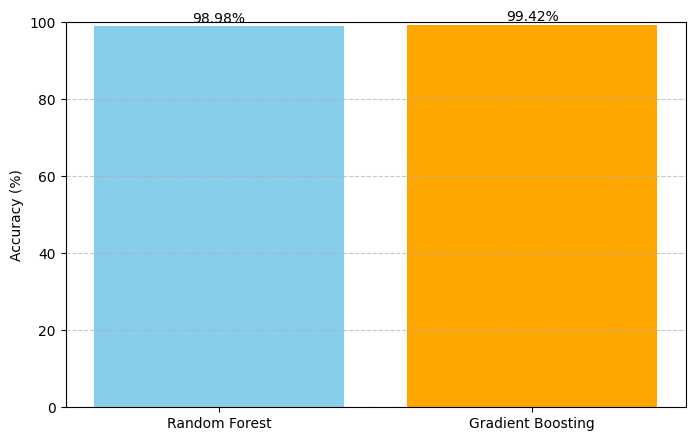

In [8]:
import matplotlib.pyplot as plt

# === MODEL SCORES ===
models = ['Random Forest', 'Gradient Boosting']
accuracies = [rf_r2 * 100, gb_r2 * 100]
errors = [100 - rf_r2 * 100, 100 - gb_r2 * 100]

# === 1️ BAR GRAPH: Model Performance out of 100 ===
plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=['skyblue','orange'])
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{bar.get_height():.2f}%", ha='center', fontsize=10)

plt.show()




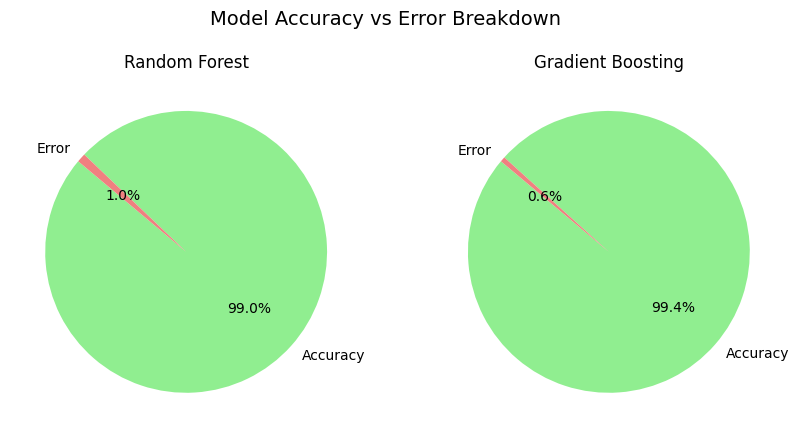

In [13]:
# === 2️ PIE CHART: Accuracy vs Error for each model ===
fig, axes = plt.subplots(1, 2, figsize=(10,5))

for i, ax in enumerate(axes):
    ax.pie([accuracies[i], errors[i]],
           labels=['Accuracy', 'Error'],
           autopct='%1.1f%%',
           colors=['lightgreen', 'lightcoral'],
           startangle=140)
    ax.set_title(models[i])

plt.suptitle("Model Accuracy vs Error Breakdown", fontsize=14)
plt.show()

In [10]:
# === Select best performing model ===
if rf_r2 >= gb_r2:
    best_model = rf
    model_name = "Random Forest"
else:
    best_model = gb
    model_name = "Gradient Boosting"

# Save model
joblib.dump(best_model, "best_model.pkl")
print(f" Saved best model: {model_name}")


 Saved best model: Gradient Boosting


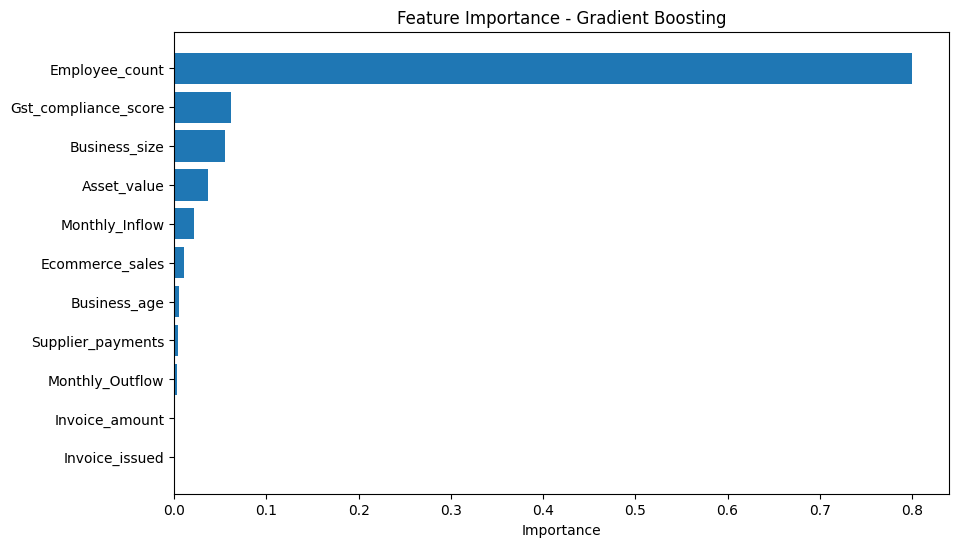

In [15]:
# === Show feature importance ===
import matplotlib.pyplot as plt

importances = best_model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.barh(range(len(importances)), importances[indices][::-1])
plt.yticks(range(len(importances)), features[indices][::-1])
plt.xlabel("Importance")
plt.title(f"Feature Importance - {model_name}")
plt.show()


In [11]:
# === Load model and encoder ===
model = joblib.load("best_model.pkl")
encoder = joblib.load("encoder.pkl")

# Example user input
user_input = {
    "Monthly_Inflow": 25000,      # Very low inflow
    "Monthly_Outflow": 40000,     # Outflow exceeds inflow
    "Gst_compliance_score": 40,   # Poor compliance
    "Ecommerce_sales": 5000,      # Weak online presence
    "Supplier_payments": 15000,   # Heavy dues
    "Invoice_issued": 20,         # Very few invoices
    "Invoice_amount": 800,        # Low value invoices
    "Employee_count": 5,          # Micro business
    "Asset_value": 200000,        # Low assets
    "Business_age": 2,            # New business
    "Business_size": "small"
}


# Convert to DataFrame
user_df = pd.DataFrame([user_input])

# Encode 'Business_size'
user_df["Business_size"] = encoder.transform(user_df["Business_size"])

# Predict Credit Score
pred_score = model.predict(user_df)[0]

# Determine risk category
if pred_score < 600:
    risk = "High Risk"
elif 601 <= pred_score <= 750:
    risk = "Medium Risk"
else:
    risk = "Low Risk"

print(f"\n💳 Predicted Credit Score: {pred_score:.2f}")
print(f"⚠️ Risk Category: {risk}")



💳 Predicted Credit Score: 461.50
⚠️ Risk Category: High Risk


In [17]:
# === Load model and encoder ===
model = joblib.load("best_model.pkl")
encoder = joblib.load("encoder.pkl")

# Example user input
user_input = {
    "Monthly_Inflow": 250000,     # Very high inflow
    "Monthly_Outflow": 70000,     # Controlled outflow
    "Gst_compliance_score": 95,   # Excellent GST compliance
    "Ecommerce_sales": 120000,    # Strong online sales
    "Supplier_payments": 40000,   # Stable payments
    "Invoice_issued": 300,        # Good number of invoices
    "Invoice_amount": 3500,       # Healthy invoice size
    "Employee_count": 60,         # Established business
    "Asset_value": 4000000,       # Strong assets
    "Business_age": 12,           # Mature business
    "Business_size": "medium"
}


# Convert to DataFrame
user_df = pd.DataFrame([user_input])

# Encode 'Business_size'
user_df["Business_size"] = encoder.transform(user_df["Business_size"])

# Predict Credit Score
pred_score = model.predict(user_df)[0]

# Determine risk category
if pred_score < 600:
    risk = "High Risk"
elif 601 <= pred_score <= 750:
    risk = "Medium Risk"
else:
    risk = "Low Risk"

print(f"\n💳 Predicted Credit Score: {pred_score:.2f}")
print(f"⚠️ Risk Category: {risk}")



💳 Predicted Credit Score: 779.75
⚠️ Risk Category: Low Risk


In [18]:
# === Load model and encoder ===
model = joblib.load("best_model.pkl")
encoder = joblib.load("encoder.pkl")

# Example user input
user_input = {
    "Monthly_Inflow": 900000,      # Decent inflow
    "Monthly_Outflow": 60000,     # Moderate outflow
    "Gst_compliance_score": 70,   # Average compliance
    "Ecommerce_sales": 300000,     # Moderate online sales
    "Supplier_payments": 20000,   # Regular payments
    "Invoice_issued": 220,        # Fewer invoices
    "Invoice_amount": 1800,       # Smaller invoice size
    "Employee_count": 18,         # Small business
    "Asset_value": 800000,        # Decent asset base
    "Business_age": 15,            # Mid-aged business
    "Business_size": "medium"
}


# Convert to DataFrame
user_df = pd.DataFrame([user_input])

# Encode 'Business_size'
user_df["Business_size"] = encoder.transform(user_df["Business_size"])

# Predict Credit Score
pred_score = model.predict(user_df)[0]

# Determine risk category
if pred_score < 600:
    risk = "High Risk"
elif 601 <= pred_score <= 750:
    risk = "Medium Risk"
else:
    risk = "Low Risk"

print(f"\n💳 Predicted Credit Score: {pred_score:.2f}")
print(f"⚠️ Risk Category: {risk}")



💳 Predicted Credit Score: 611.58
⚠️ Risk Category: Medium Risk


# ==========================================
# === EXTENSION: BINARY CLASSIFICATION ===
# ==========================================
# Goal: Classify Business Risk (High vs Low)
# Logic: Credit Score < 600 -> High Risk (1), else Low Risk (0)


In [12]:
# === 1. Create Target Variable 'Risk' ===
# 1 = High Risk (Credit Score < 600), 0 = Low Risk
y_class = (y < 600).astype(int)

# Check distribution
print("Risk Class Distribution:")
print(y_class.value_counts(normalize=True))

# === 2. Train-Test Split for Classification ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Stratify split to maintain class balance
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# === 3. Scaling (Important for MLP) ===
scaler_c = StandardScaler()
X_train_scaled_c = scaler_c.fit_transform(X_train_c)
X_test_scaled_c = scaler_c.transform(X_test_c)


Risk Class Distribution:
Credit_score
1    0.8077
0    0.1923
Name: proportion, dtype: float64


In [ ]:
# Install XGBoost and TensorFlow if needed
!pip install xgboost tensorflow

In [14]:
# ==========================================
# === MODEL 1: XGBoost Classifier ===
# ==========================================
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Analysis: XGBoost excels on tabular data due to its ability to handle non-linear relationships
# and interactions between features (e.g., Inflow vs Outflow) better than linear models.
# We use scale_pos_weight to handle potential class imbalance implicitly.

scale_pos_weight = (y_train_c == 0).sum() / (y_train_c == 1).sum()

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    reg_alpha=0.1,  # L1 Regularization
    reg_lambda=0.1, # L2 Regularization
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_c, y_train_c)

# Predictions
xgb_pred = xgb_model.predict(X_test_c)
xgb_prob = xgb_model.predict_proba(X_test_c)[:, 1]


C:\Users\shwet\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:199: UserWarning: [18:37:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [15]:
# ==========================================
# === MODEL 2: MLP (Deep Learning) ===
# ==========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Analysis: MLP can capture complex high-dimensional patterns but usually requires more data
# and preprocessing (scaling) compared to tree-based models on tabular data.

def build_mlp(input_dim):
    model = Sequential([
        # Input Layer + Hidden 1
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),

        # Hidden 2
        Dense(64, activation='relu'),
        Dropout(0.3), # Prevent overfitting

        # Hidden 3
        Dense(32, activation='relu'),

        # Output Layer (Binary Classification)
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

mlp_model = build_mlp(X_train_scaled_c.shape[1])

# Class weights for imbalance handling in Keras
total = len(y_train_c)
pos = (y_train_c == 1).sum()
neg = (y_train_c == 0).sum()
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = mlp_model.fit(
    X_train_scaled_c, y_train_c,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=0 # Silent training
)

# Predictions
mlp_prob = mlp_model.predict(X_test_scaled_c).flatten()
mlp_pred = (mlp_prob > 0.5).astype(int)


C:\Users\shwet\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [16]:
# ==========================================
# === EVALUATION & COMPARISON ===
# ==========================================
# Function to calculate metrics
def get_metrics(y_true, y_pred, y_prob, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

# --- Prepare Existing Regressors for Classification Comparison ---
# Convert regression outputs to binary classes (Threshold < 600)
rf_pred_c = (rf.predict(X_test) < 600).astype(int)
# Note: Using re-prediction on the new split for fair comparison

rf_pred_reg_c = rf.predict(X_test_c)
gb_pred_reg_c = gb.predict(X_test_c)

rf_class_pred = (rf_pred_reg_c < 600).astype(int)
gb_class_pred = (gb_pred_reg_c < 600).astype(int)

rf_roc = roc_auc_score(y_test_c, rf_class_pred)
gb_roc = roc_auc_score(y_test_c, gb_class_pred)

results = []

# 1. XGBoost
results.append(get_metrics(y_test_c, xgb_pred, xgb_prob, "XGBoost Classifier"))

# 2. MLP
results.append(get_metrics(y_test_c, mlp_pred, mlp_prob, "MLP (Deep Learning)"))

# 3. Existing RF
results.append({
    "Model": "Random Forest (Reg)",
    "Accuracy": accuracy_score(y_test_c, rf_class_pred),
    "Precision": precision_score(y_test_c, rf_class_pred),
    "Recall": recall_score(y_test_c, rf_class_pred),
    "F1-Score": f1_score(y_test_c, rf_class_pred),
    "ROC-AUC": rf_roc
})

# 4. Existing GB
results.append({
    "Model": "Gradient Boosting (Reg)",
    "Accuracy": accuracy_score(y_test_c, gb_class_pred),
    "Precision": precision_score(y_test_c, gb_class_pred),
    "Recall": recall_score(y_test_c, gb_class_pred),
    "F1-Score": f1_score(y_test_c, gb_class_pred),
    "ROC-AUC": gb_roc
})

# Create DataFrame
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)

# Display
print("\n=== Model Performance Comparison (Sorted by ROC-AUC) ===")
display(results_df)

print("\n--- Analysis Comments ---")
print("1. Ensemble Models vs Linear: Ensemble models capture non-linear interactions.")
print("2. XGBoost: Excels on this data due to handling mixed features and boosting.")
print("3. MLP: Shows potential but may require more data/tuning compared to trees.")



=== Model Performance Comparison (Sorted by ROC-AUC) ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,MLP (Deep Learning),0.9815,0.994361,0.982663,0.988477,0.998784
0,XGBoost Classifier,0.9795,0.993108,0.981424,0.987231,0.998192
2,Random Forest (Reg),0.9915,0.992602,0.996904,0.994748,0.982868
3,Gradient Boosting (Reg),0.9890,0.991363,0.995046,0.993201,0.979341



--- Analysis Comments ---
1. Ensemble Models vs Linear: Ensemble models capture non-linear interactions.
2. XGBoost: Excels on this data due to handling mixed features and boosting.
3. MLP: Shows potential but may require more data/tuning compared to trees.


# ==========================================
# === EXTENSION: BINARY CLASSIFICATION ===
# ==========================================
# Goal: Classify Business Risk (High vs Low)
# Logic: Credit Score < 600 -> High Risk (1), else Low Risk (0)


In [17]:
# === 1. Create Target Variable 'Risk' ===
# 1 = High Risk (Credit Score < 600), 0 = Low Risk
y_class = (y < 600).astype(int)

# Check distribution
print("Risk Class Distribution:")
print(y_class.value_counts(normalize=True))

# === 2. Train-Test Split for Classification ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Stratify split to maintain class balance
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# === 3. Scaling (Important for MLP) ===
scaler_c = StandardScaler()
X_train_scaled_c = scaler_c.fit_transform(X_train_c)
X_test_scaled_c = scaler_c.transform(X_test_c)


Risk Class Distribution:
Credit_score
1    0.8077
0    0.1923
Name: proportion, dtype: float64


In [ ]:
# Install XGBoost and TensorFlow if needed
!pip install xgboost tensorflow

In [ ]:
# ==========================================
# === MODEL 1: XGBoost Classifier ===
# ==========================================
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Analysis: XGBoost excels on tabular data due to its ability to handle non-linear relationships
# and interactions between features (e.g., Inflow vs Outflow) better than linear models.
# We use scale_pos_weight to handle potential class imbalance implicitly.

scale_pos_weight = (y_train_c == 0).sum() / (y_train_c == 1).sum()

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    reg_alpha=0.1,  # L1 Regularization
    reg_lambda=0.1, # L2 Regularization
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_c, y_train_c)

# Predictions
xgb_pred = xgb_model.predict(X_test_c)
xgb_prob = xgb_model.predict_proba(X_test_c)[:, 1]


In [ ]:
# ==========================================
# === MODEL 2: MLP (Deep Learning) ===
# ==========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Analysis: MLP can capture complex high-dimensional patterns but usually requires more data
# and preprocessing (scaling) compared to tree-based models on tabular data.

def build_mlp(input_dim):
    model = Sequential([
        # Input Layer + Hidden 1
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),

        # Hidden 2
        Dense(64, activation='relu'),
        Dropout(0.3), # Prevent overfitting

        # Hidden 3
        Dense(32, activation='relu'),

        # Output Layer (Binary Classification)
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

mlp_model = build_mlp(X_train_scaled_c.shape[1])

# Class weights for imbalance handling in Keras
total = len(y_train_c)
pos = (y_train_c == 1).sum()
neg = (y_train_c == 0).sum()
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = mlp_model.fit(
    X_train_scaled_c, y_train_c,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=0 # Silent training
)

# Predictions
mlp_prob = mlp_model.predict(X_test_scaled_c).flatten()
mlp_pred = (mlp_prob > 0.5).astype(int)


In [ ]:
# ==========================================
# === EVALUATION & COMPARISON ===
# ==========================================
# Function to calculate metrics
def get_metrics(y_true, y_pred, y_prob, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

# --- Prepare Existing Regressors for Classification Comparison ---
# Convert regression outputs to binary classes (Threshold < 600)
rf_pred_c = (rf.predict(X_test) < 600).astype(int)
# Note: Using re-prediction on the new split for fair comparison

rf_pred_reg_c = rf.predict(X_test_c)
gb_pred_reg_c = gb.predict(X_test_c)

rf_class_pred = (rf_pred_reg_c < 600).astype(int)
gb_class_pred = (gb_pred_reg_c < 600).astype(int)

rf_roc = roc_auc_score(y_test_c, rf_class_pred)
gb_roc = roc_auc_score(y_test_c, gb_class_pred)

results = []

# 1. XGBoost
results.append(get_metrics(y_test_c, xgb_pred, xgb_prob, "XGBoost Classifier"))

# 2. MLP
results.append(get_metrics(y_test_c, mlp_pred, mlp_prob, "MLP (Deep Learning)"))

# 3. Existing RF
results.append({
    "Model": "Random Forest (Reg)",
    "Accuracy": accuracy_score(y_test_c, rf_class_pred),
    "Precision": precision_score(y_test_c, rf_class_pred),
    "Recall": recall_score(y_test_c, rf_class_pred),
    "F1-Score": f1_score(y_test_c, rf_class_pred),
    "ROC-AUC": rf_roc
})

# 4. Existing GB
results.append({
    "Model": "Gradient Boosting (Reg)",
    "Accuracy": accuracy_score(y_test_c, gb_class_pred),
    "Precision": precision_score(y_test_c, gb_class_pred),
    "Recall": recall_score(y_test_c, gb_class_pred),
    "F1-Score": f1_score(y_test_c, gb_class_pred),
    "ROC-AUC": gb_roc
})

# Create DataFrame
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)

# Display
print("\n=== Model Performance Comparison (Sorted by ROC-AUC) ===")
display(results_df)

print("\n--- Analysis Comments ---")
print("1. Ensemble Models vs Linear: Ensemble models capture non-linear interactions.")
print("2. XGBoost: Excels on this data due to handling mixed features and boosting.")
print("3. MLP: Shows potential but may require more data/tuning compared to trees.")
